In [112]:
#Tree Based Methods
# Decision Tree
# Random Forest
# Ada Boost
# Gradient Boosting
# XG Boost
# LightGBM

#Datasets
# Make Moons
# Standard Classification Metrics


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [114]:
def evaluate_model(model,X_train,X_test,Y_train,Y_test):
    model.fit(X_train,Y_train)

    print("Train Done")

    y_pred = model.predict(X_test)

    print("Test Done")

    y_prob = model.predict_proba(X_test)[:,1]

    print("Accuracy : ",accuracy_score(Y_test,y_pred))
    print("Confusion Matrix : \n",confusion_matrix(Y_test,y_pred))
    print("Classification Report : \n",classification_report(Y_test,y_pred))
    print("ROC AUC Score : ",roc_auc_score(Y_test,y_prob))

    fpr,tpr,thresholds = roc_curve(Y_test,y_prob)

    plt.figure(figsize = (7,6))
    plt.plot(fpr,tpr,label = "ROC Curve")

    plt.plot([0,1],[0,1],linestyle = "--",label = "Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

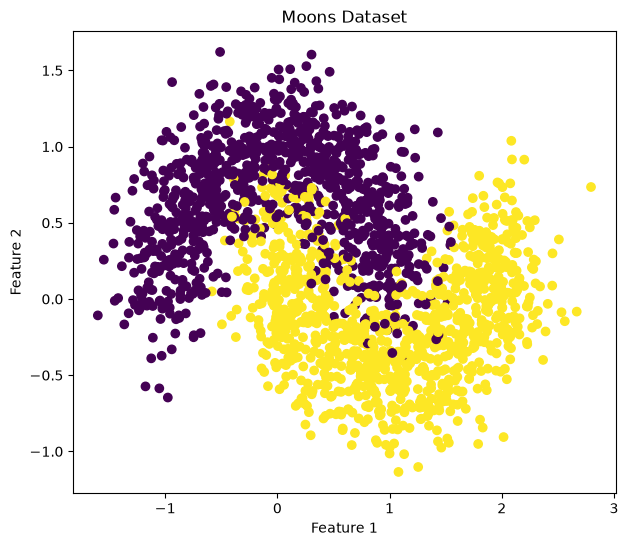

In [115]:
from sklearn.datasets import make_moons,make_circles,make_classification,make_blobs

X ,y = make_moons(
    n_samples = 2000,
    noise = 0.25,
    random_state = 182
)

plt.figure(figsize = (7,6))
plt.scatter(X[:,0],X[:,1],c = y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

In [116]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(1600, 2)
(400, 2)
(1600,)
(400,)


Train Done
Test Done
Accuracy :  0.9075
Confusion Matrix : 
 [[174  19]
 [ 18 189]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.91      0.90      0.90       193
           1       0.91      0.91      0.91       207

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400

ROC AUC Score :  0.9072989412029737


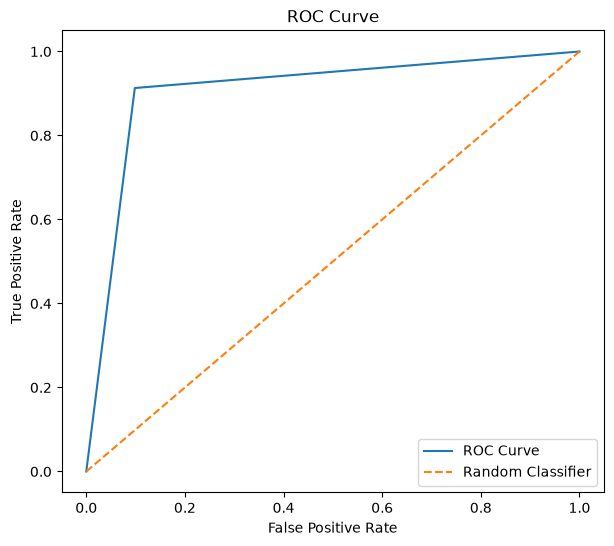

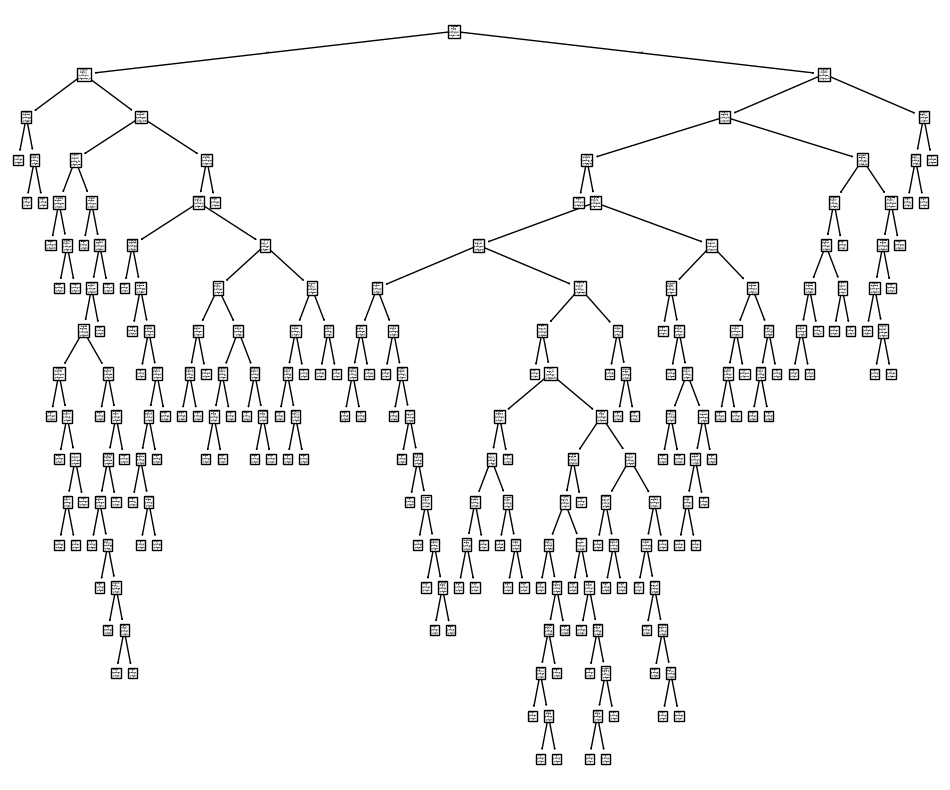

In [117]:
#Decision Tree
dt_model = DecisionTreeClassifier()
evaluate_model(dt_model,X_train,X_test,Y_train,Y_test)
#print the model
from sklearn.tree import plot_tree
plt.figure(figsize=(12,10))
plot_tree(dt_model)
plt.show()

Train Done
Test Done
Accuracy :  0.89
Confusion Matrix : 
 [[174  19]
 [ 25 182]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.87      0.90      0.89       193
           1       0.91      0.88      0.89       207

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400

ROC AUC Score :  0.9410653049986233


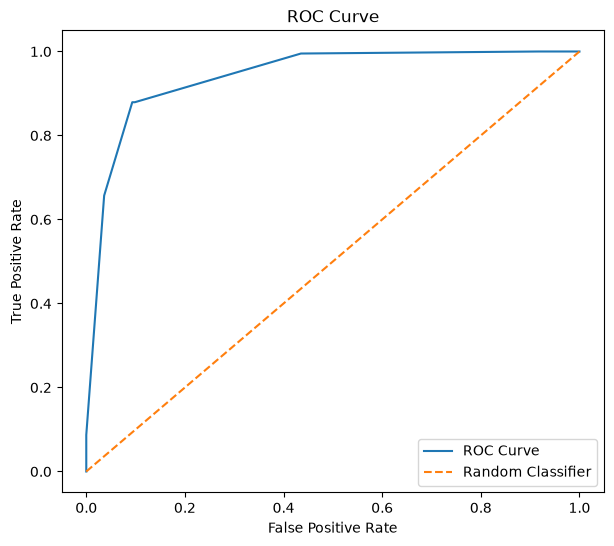

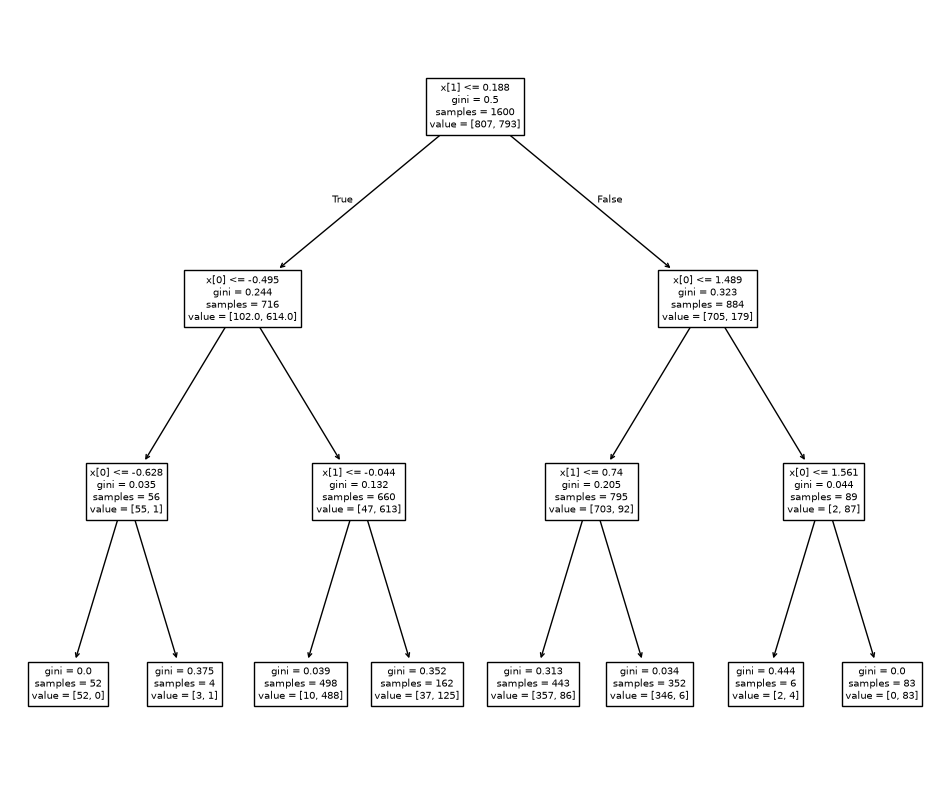

In [118]:
#Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3)
evaluate_model(dt_model,X_train,X_test,Y_train,Y_test)
#print the model
from sklearn.tree import plot_tree
plt.figure(figsize=(12,10))
plot_tree(dt_model)
plt.show()

Train Done
Test Done
Accuracy :  0.8925
Confusion Matrix : 
 [[175  18]
 [ 25 182]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.88      0.91      0.89       193
           1       0.91      0.88      0.89       207

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400

ROC AUC Score :  0.9640684838927686


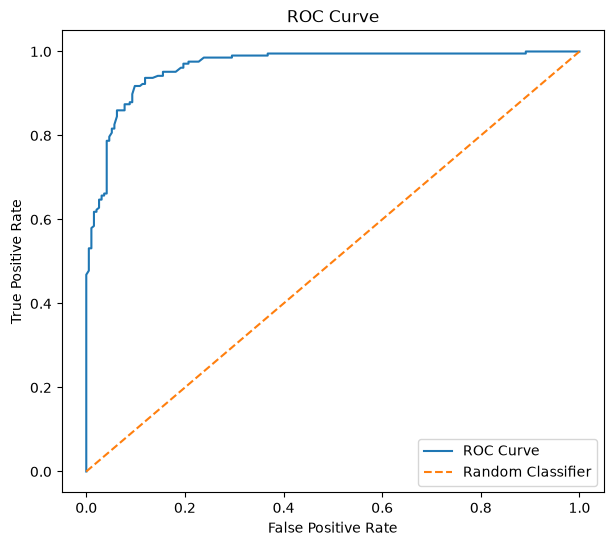

In [119]:
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    bootstrap=True,
    random_state=42
)
evaluate_model(rf_model,X_train,X_test,Y_train,Y_test)




Train Done
Test Done
Accuracy :  0.8975
Confusion Matrix : 
 [[174  19]
 [ 22 185]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.89      0.90      0.89       193
           1       0.91      0.89      0.90       207

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400

ROC AUC Score :  0.9583990388225576


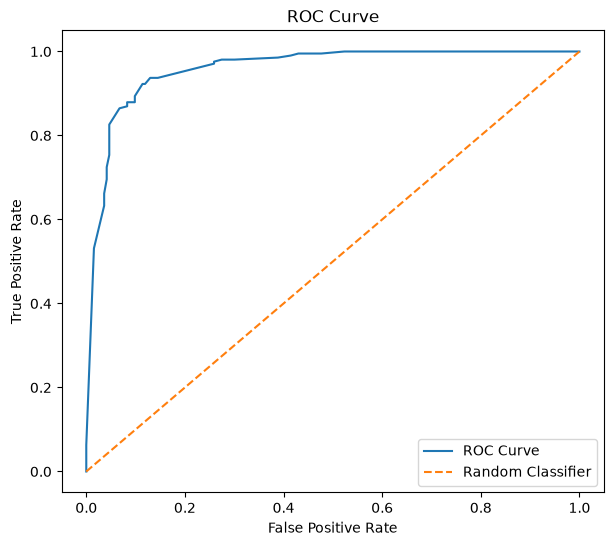

In [120]:
#Bagging Methods
bagging_model = BaggingClassifier(
    estimator = DecisionTreeClassifier(max_depth = 3),
    n_estimators = 50,
    bootstrap = True,
    random_state = 42
)

evaluate_model(bagging_model,X_train,X_test,Y_train,Y_test)

Train Done
Test Done
Accuracy :  0.93
Confusion Matrix : 
 [[176  17]
 [ 11 196]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.94      0.91      0.93       193
           1       0.92      0.95      0.93       207

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

ROC AUC Score :  0.98395534529799


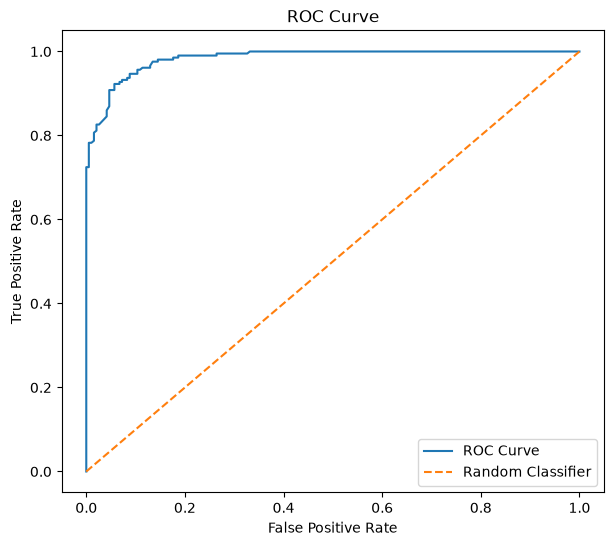

In [121]:
#Adaboost
ada_model = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(max_depth = 3),
    n_estimators = 50,
    random_state = 42
)

evaluate_model(ada_model,X_train,X_test,Y_train,Y_test)

Train Done
Test Done
Accuracy :  0.93
Confusion Matrix : 
 [[180  13]
 [ 15 192]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       193
           1       0.94      0.93      0.93       207

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

ROC AUC Score :  0.9807389051588195


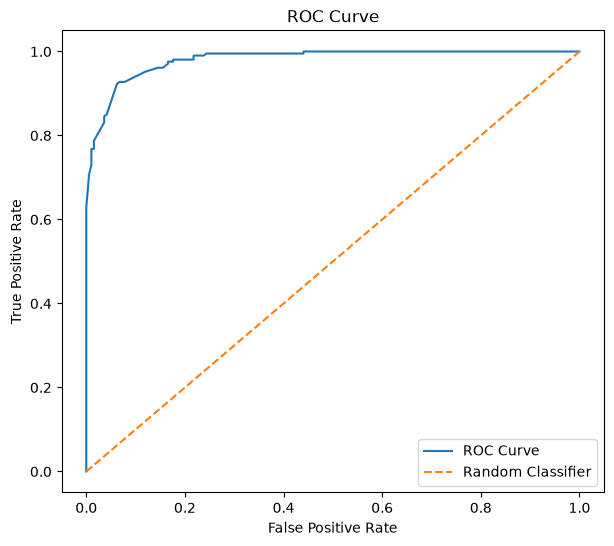

In [122]:
ada_model = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(max_depth = 1),
    n_estimators = 50,
    random_state = 42
)

evaluate_model(ada_model,X_train,X_test,Y_train,Y_test)

In [123]:
print("Weights of the first 10 estimators")
print(ada_model.estimator_weights_[:10])

Weights of the first 10 estimators
[1.54627448 1.0327396  1.2224392  0.83984042 0.590756   0.64469499
 0.58302571 0.6002277  0.4923768  0.66457104]


In [124]:
print(ada_model.estimator_errors_[:10])

[0.175625   0.26255332 0.22750748 0.3015684  0.35646141 0.344186
 0.35823668 0.3542916  0.37933381 0.33971354]


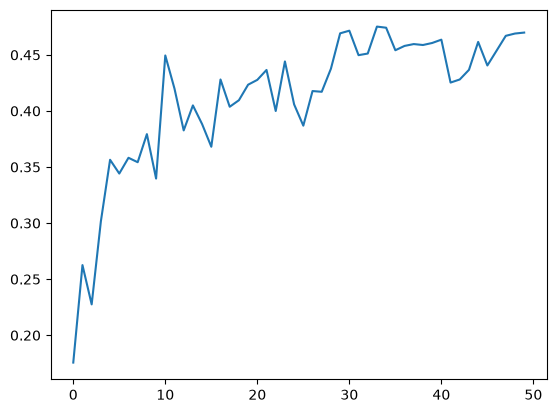

In [125]:
plt.plot(ada_model.estimator_errors_)

Train Done
Test Done
Accuracy :  0.9275
Confusion Matrix : 
 [[180  13]
 [ 16 191]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       193
           1       0.94      0.92      0.93       207

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

ROC AUC Score :  0.9788240594728542


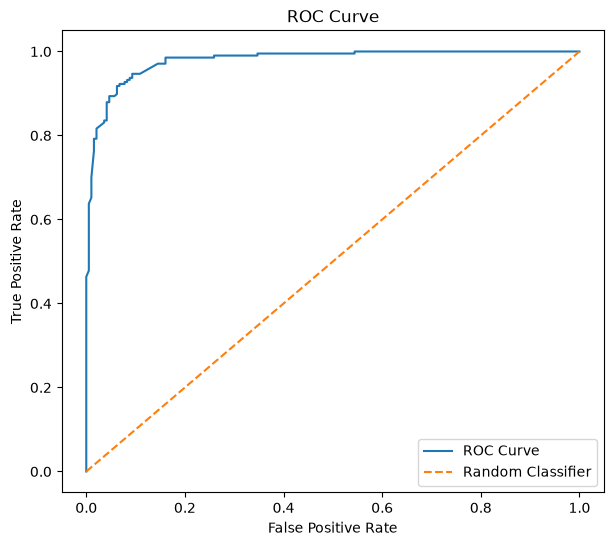

In [126]:
#Gradient Boosting
grad_boost_model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    random_state=42,
    
)
evaluate_model(grad_boost_model,X_train,X_test,Y_train,Y_test)

Train Done
Test Done
Accuracy :  0.9275
Confusion Matrix : 
 [[179  14]
 [ 15 192]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       193
           1       0.93      0.93      0.93       207

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

ROC AUC Score :  0.98105178844084


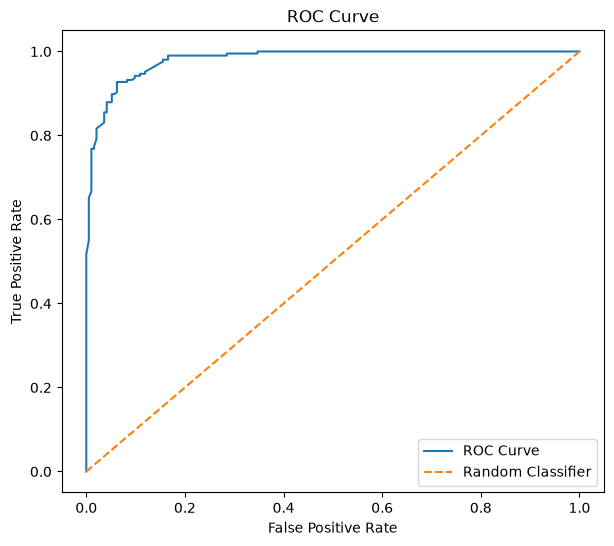

In [127]:
#XGBOOST
xgb_model = XGBClassifier(
    n_estimators = 50,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)

evaluate_model(xgb_model,X_train,X_test,Y_train,Y_test)

[LightGBM] [Info] Number of positive: 793, number of negative: 807
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495625 -> initscore=-0.017500
[LightGBM] [Info] Start training from score -0.017500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

/Users/mukundanramesh/projects/ai_ml_course_bootcamp_practice/aiml_venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/mukundanramesh/projects/ai_ml_course_bootcamp_practice/aiml_venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


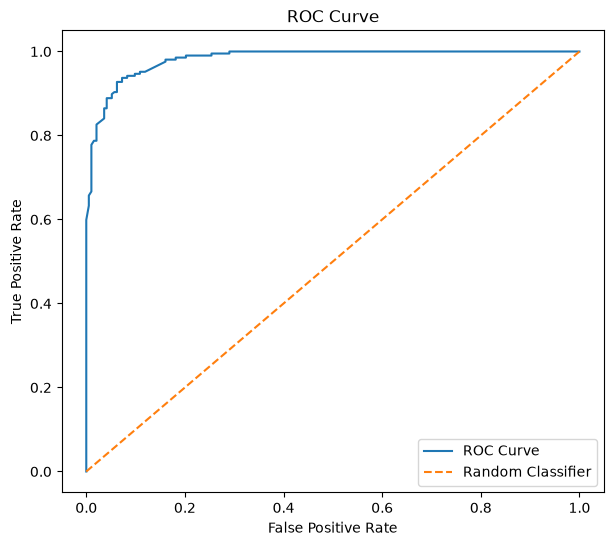

In [128]:
# Light GBM

lgbm_model = LGBMClassifier(
    n_estimators = 50,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)

evaluate_model(lgbm_model,X_train,X_test,Y_train,Y_test)

Train Done
Test Done
Accuracy :  0.9225
Confusion Matrix : 
 [[177  16]
 [ 15 192]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       193
           1       0.92      0.93      0.93       207

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400

ROC AUC Score :  0.9853820930640035


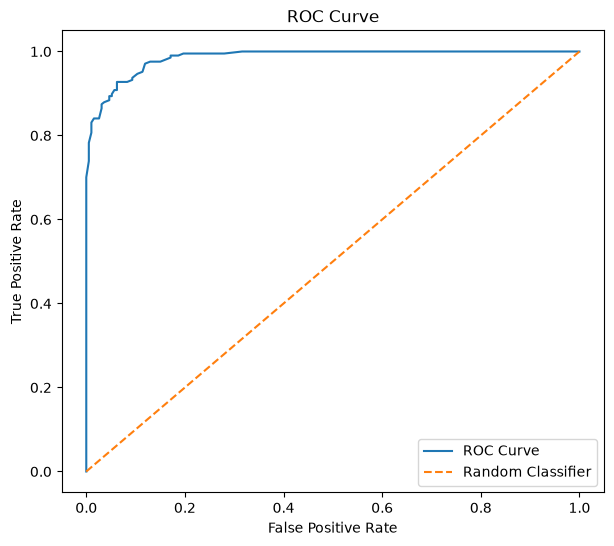

In [129]:
#KNN 

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 51)

evaluate_model(knn_model,X_train,X_test,Y_train,Y_test)


Train Done
Test Done
Accuracy :  0.93
Confusion Matrix : 
 [[179  14]
 [ 14 193]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.93      0.93      0.93       193
           1       0.93      0.93      0.93       207

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

ROC AUC Score :  0.9850566944507021


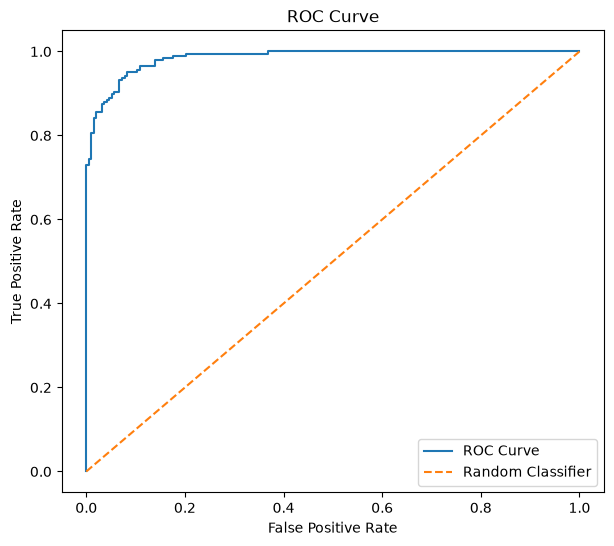

In [130]:
#SVM Classifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

#svm_model = SVC(kernel = "rbf",probability = True)
svm_model = CalibratedClassifierCV(SVC(kernel = "rbf"), ensemble=False)
evaluate_model(svm_model,X_train,X_test,Y_train,Y_test)

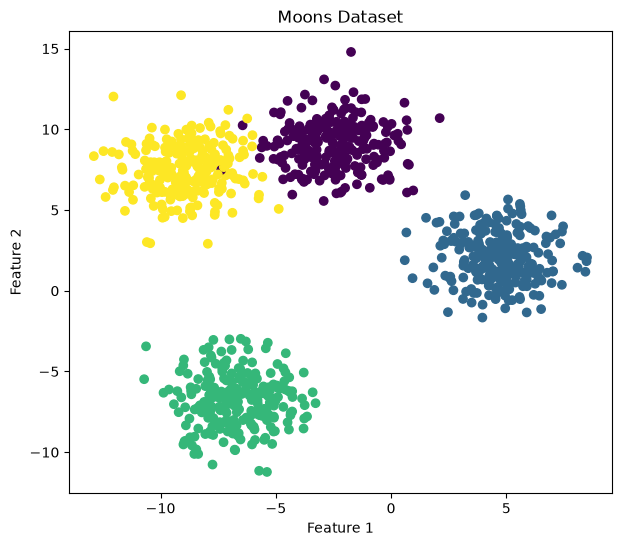

In [131]:
# Clustering : K-Means, Hirarical and DBSCAN


from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN

X,y = make_blobs(n_samples = 1000,n_features = 2,centers = 4,cluster_std = 1.5,random_state = 42)

plt.figure(figsize = (7,6))
plt.scatter(X[:,0],X[:,1],c = y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

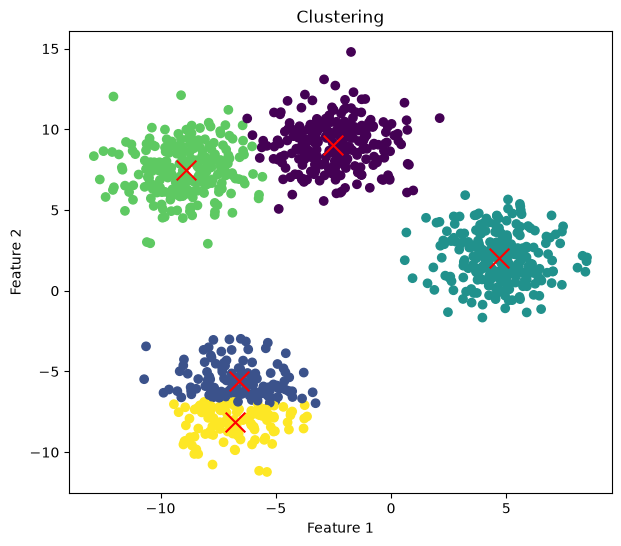

In [132]:
k_means = KMeans(n_clusters = 5,random_state = 42)

k_means.fit(X)

labels = k_means.labels_
centroids = k_means.cluster_centers_

plt.figure(figsize = (7,6))
plt.scatter(X[:,0],X[:,1],c = labels)
plt.scatter(centroids[:,0],centroids[:,1],marker = "x",s = 200,color = "red")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Clustering")
plt.show()

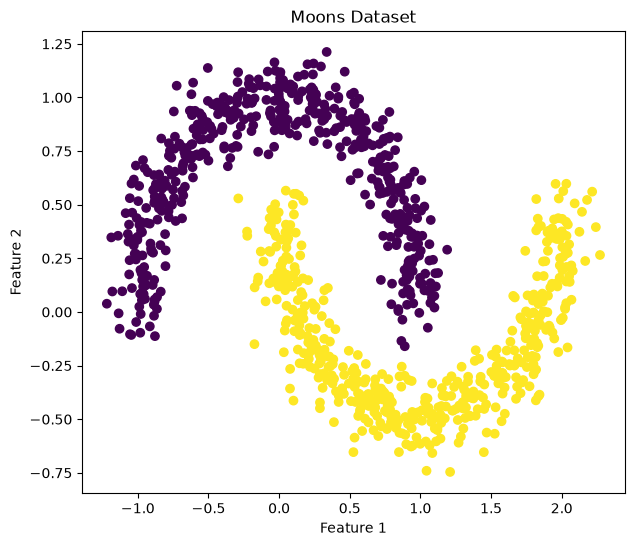

In [133]:
X_moons,y_moons = make_moons(n_samples = 1000,noise = 0.1,random_state = 42)

plt.figure(figsize = (7,6))
plt.scatter(X_moons[:,0],X_moons[:,1],c = y_moons)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

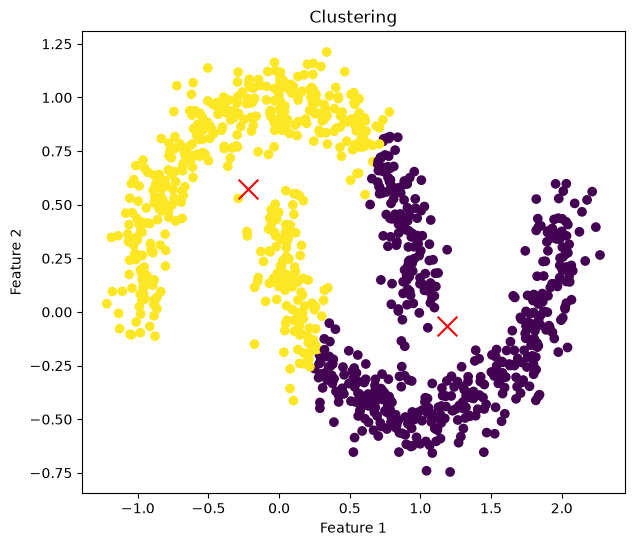

In [134]:
# K-Means Clustering on Moons Data

k_means = KMeans(n_clusters = 2,random_state = 42)

k_means.fit(X_moons)

labels = k_means.labels_
centroids = k_means.cluster_centers_

plt.figure(figsize = (7,6))
plt.scatter(X_moons[:,0],X_moons[:,1],c = labels)

plt.scatter(centroids[:,0],centroids[:,1],marker = "x",s = 200,color = "red")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Clustering")
plt.show()

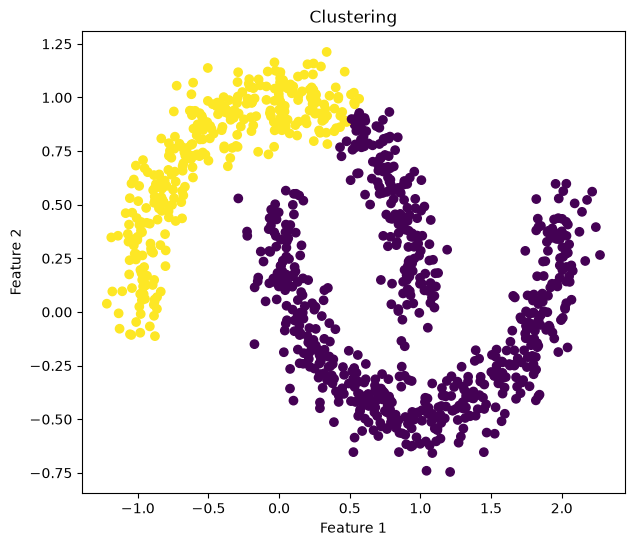

In [135]:
# AgglomerativeClustering

agg_model = AgglomerativeClustering(n_clusters = 2)

labels = agg_model.fit_predict(X_moons)


plt.figure(figsize = (7,6))
plt.scatter(X_moons[:,0],X_moons[:,1],c = labels)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Clustering")
plt.show()

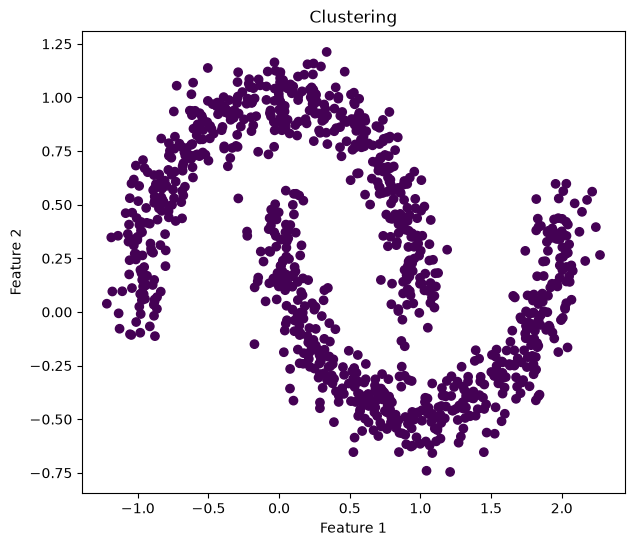

In [136]:
# DBSCAN

dbscan_model = DBSCAN(eps = 0.03,min_samples = 11)

labels = dbscan_model.fit_predict(X_moons)


plt.figure(figsize = (7,6))
plt.scatter(X_moons[:,0],X_moons[:,1],c = labels)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Clustering")
plt.show()

In [137]:
# Grid Search on SVM for Classification

# C = 0.1,1,10,100
# gamma = 0.001,0.01,0.1,1

# 4 x 4 -> 16 Combinations to try with

In [138]:
# GridCV

from sklearn.model_selection import (GridSearchCV,RandomizedSearchCV)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target


print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [139]:
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [140]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [141]:
svc_pipeline = Pipeline(
    [
        ("scaler",StandardScaler()),
        ("svm",SVC())
    ]
)

svc_pipeline.fit(X_train,Y_train)

print("Train Done")

y_pred = svc_pipeline.predict(X_test)

print("Test Done")


print("Accuracy : ",accuracy_score(Y_test,y_pred))
print("Confusion Matrix : \n",confusion_matrix(Y_test,y_pred))
print("Classification Report : \n",classification_report(Y_test,y_pred))

Train Done
Test Done
Accuracy :  0.9824561403508771
Confusion Matrix : 
 [[41  2]
 [ 0 71]]
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



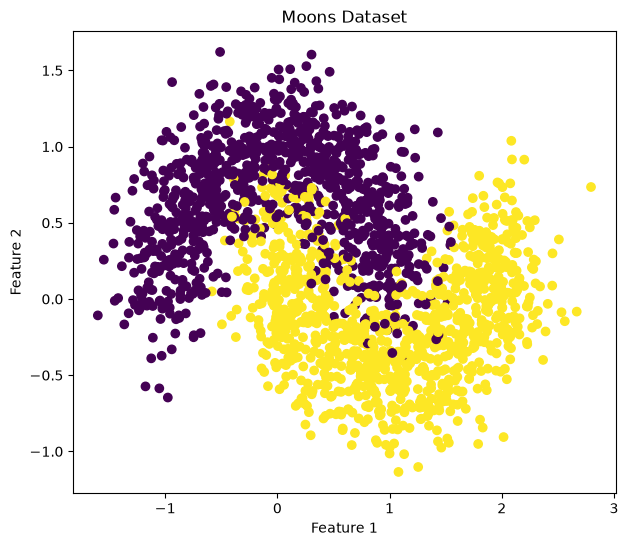

Train Done
Test Done
Accuracy :  0.9275
Confusion Matrix : 
 [[179  14]
 [ 15 192]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       193
           1       0.93      0.93      0.93       207

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



In [142]:
X,y = make_moons(
    n_samples = 2000,
    noise = 0.25,
    random_state = 182
)

X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

plt.figure(figsize = (7,6))
plt.scatter(X[:,0],X[:,1],c = y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

svc_pipeline = Pipeline(
    [
        ("scaler",StandardScaler()),
        ("svm",SVC())
    ]
)

svc_pipeline.fit(X_train,Y_train)

print("Train Done")

y_pred = svc_pipeline.predict(X_test)

print("Test Done")


print("Accuracy : ",accuracy_score(Y_test,y_pred))
print("Confusion Matrix : \n",confusion_matrix(Y_test,y_pred))
print("Classification Report : \n",classification_report(Y_test,y_pred))

In [143]:
param_grid = {
    "svm__C":[0.1,1,10,100],
    "svm__gamma":[0.001,0.01,0.1,1]
}

grid_search = GridSearchCV(svc_pipeline,param_grid,cv = 5)

grid_search.fit(X_train,Y_train)

print("Best Parameters : ",grid_search.best_params_)

Best Parameters :  {'svm__C': 10, 'svm__gamma': 1}


In [144]:
print(grid_search.best_score_)

0.9393750000000001


In [145]:
# Evaluation using the best parameters

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy : ",accuracy_score(Y_test,y_pred))

print("Confusion Matrix : \n",confusion_matrix(Y_test,y_pred))

print("Classification Report : \n",classification_report(Y_test,y_pred))

Accuracy :  0.92
Confusion Matrix : 
 [[176  17]
 [ 15 192]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       193
           1       0.92      0.93      0.92       207

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



In [146]:
import numpy as np
from scipy.stats import loguniform,uniform

# To get random samples from a frozen distribution, use the .rvs() method.
# For example, to get 5 random samples from loguniform distribution:
print(loguniform(0.001,10).rvs(size=10))

# To get 5 random samples from uniform distribution:
print(uniform(0.001,1).rvs(size=5))

[4.26395782e-03 4.42620138e+00 1.58439811e-01 1.45119423e+00
 7.10088702e-03 4.92884692e-01 2.08150039e-01 2.18360580e-03
 1.12397422e-02 3.78868267e-03]
[0.85524065 0.415036   0.36780414 0.10460107 0.34372363]


In [147]:
param_grid = {
    "svm__C":loguniform(0.001,10),
    "svm__gamma":loguniform(0.001,10)
}

random_search = RandomizedSearchCV(svc_pipeline,param_grid,cv = 5)

random_search.fit(X_train,Y_train)

print("Best Parameters : ",random_search.best_params_)

Best Parameters :  {'svm__C': np.float64(0.05871763061058785), 'svm__gamma': np.float64(5.751139963168913)}


In [148]:
best_random_model = random_search.best_estimator_

y_pred = best_random_model.predict(X_test)

print("Accuracy : ",accuracy_score(Y_test,y_pred))

print("Confusion Matrix : \n",confusion_matrix(Y_test,y_pred))

print("Classification Report : \n",classification_report(Y_test,y_pred))

Accuracy :  0.9275
Confusion Matrix : 
 [[180  13]
 [ 16 191]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       193
           1       0.94      0.92      0.93       207

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

